# Fund Performance Analytics

## Capstone Project I – Mutual Fund Analytics

### Objective

Evaluate the performance of mutual fund schemes using financial metrics such as Daily Returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, Fund Scorecard, and Benchmark Comparison.

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [11]:
fund_master = pd.read_csv("../dataset/raw/01_fund_master.csv")
nav = pd.read_csv("../dataset/raw/02_nav_history.csv")
aum = pd.read_csv("../dataset/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../dataset/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../dataset/raw/05_category_inflows.csv")
folio = pd.read_csv("../dataset/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../dataset/raw/07_scheme_performance.csv")
investor = pd.read_csv("../dataset/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../dataset/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../dataset/raw/10_benchmark_indices.csv")

## Daily Return Analysis

### Objective

Calculate daily returns for all mutual fund schemes and validate whether the return distribution is reasonable.

In [12]:
# Check Daily Returns

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [13]:
print(nav.head())
print(nav.columns.tolist())

      amfi_code        date       nav  daily_return
5750     100016  2022-01-03  520.4608           NaN
5751     100016  2022-01-04  515.0971     -0.010306
5752     100016  2022-01-05  521.7239      0.012865
5753     100016  2022-01-06  515.7880     -0.011377
5754     100016  2022-01-07  515.1639     -0.001210
['amfi_code', 'date', 'nav', 'daily_return']


In [14]:
print(nav["daily_return"].describe())


count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


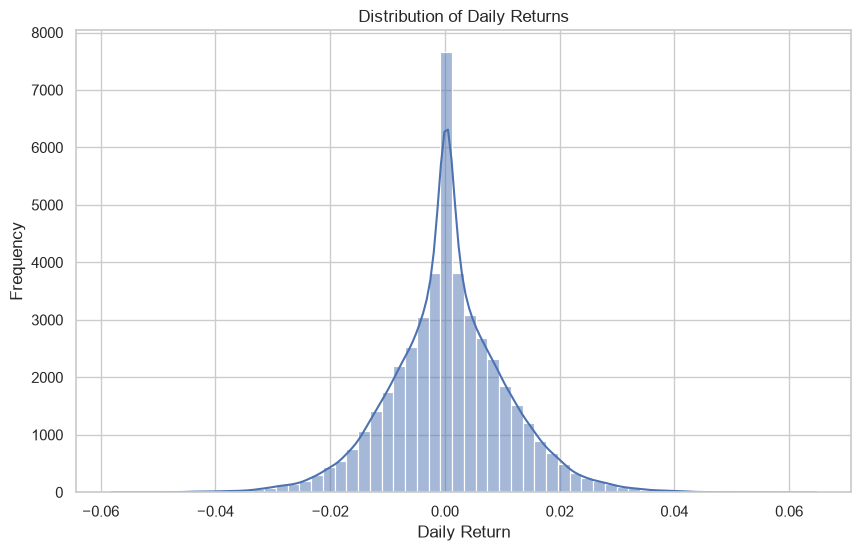

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

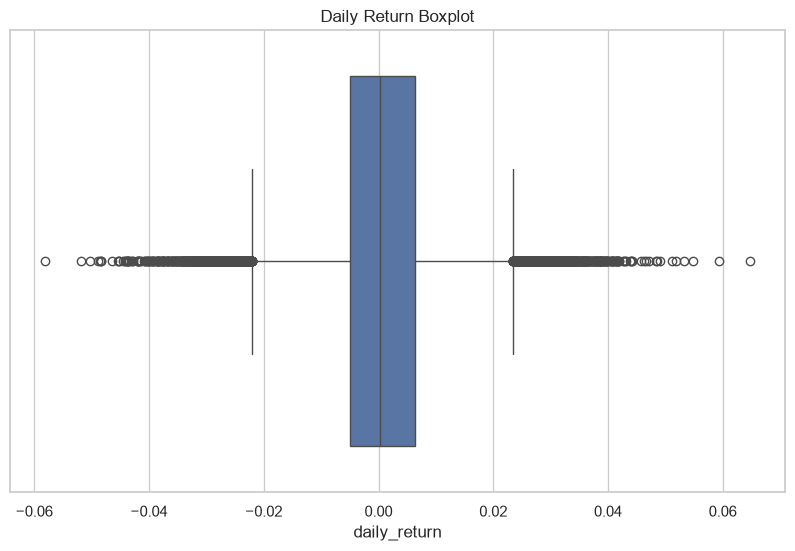

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=nav["daily_return"].dropna()
)

plt.title("Daily Return Boxplot")

plt.show()

### Business Insight

- Most daily returns are concentrated around zero, indicating normal day-to-day market movement.
- A few extreme positive and negative returns represent periods of high market volatility.
- Overall, the return distribution appears realistic for equity mutual funds.

## CAGR Analysis

### Objective

Calculate the Compound Annual Growth Rate (CAGR) for each mutual fund scheme over 1-Year, 3-Year, and 5-Year periods to compare long-term performance.

In [17]:
print(nav.head())
print(nav.columns.tolist())

      amfi_code        date       nav  daily_return
5750     100016  2022-01-03  520.4608           NaN
5751     100016  2022-01-04  515.0971     -0.010306
5752     100016  2022-01-05  521.7239      0.012865
5753     100016  2022-01-06  515.7880     -0.011377
5754     100016  2022-01-07  515.1639     -0.001210
['amfi_code', 'date', 'nav', 'daily_return']


In [18]:
# Latest NAV for each mutual fund

latest_nav = (
    nav.sort_values("date")
       .groupby("amfi_code")
       .last()
       .reset_index()
)

latest_nav = latest_nav[
    ["amfi_code", "date", "nav"]
]

latest_nav.columns = [
    "amfi_code",
    "latest_date",
    "latest_nav"
]

latest_nav.head()

,amfi_code,latest_date,latest_nav
0,100016,2026-05-29,583.6113
1,100025,2026-05-29,31.8843
2,100033,2026-05-29,342.0072
3,101206,2026-05-29,773.2939
4,101207,2026-05-29,53.9836


In [19]:
print(latest_nav.head())

   amfi_code latest_date  latest_nav
0     100016  2026-05-29    583.6113
1     100025  2026-05-29     31.8843
2     100033  2026-05-29    342.0072
3     101206  2026-05-29    773.2939
4     101207  2026-05-29     53.9836


In [20]:
# ==========================
# CAGR Calculation (1Y, 3Y, 5Y)
# ==========================

# Ensure date is datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].sort_values("date")

    latest_date = fund_data["date"].max()
    latest_nav = fund_data.iloc[-1]["nav"]

    row = {
        "amfi_code": fund,
        "latest_date": latest_date,
        "latest_nav": latest_nav
    }

    for yrs in [1, 3, 5]:

        target_date = latest_date - pd.DateOffset(years=yrs)

        previous = fund_data[fund_data["date"] <= target_date]

        if previous.empty:
            row[f"CAGR_{yrs}Y"] = np.nan
        else:
            start_nav = previous.iloc[-1]["nav"]

            row[f"CAGR_{yrs}Y"] = (
                (latest_nav / start_nav) ** (1 / yrs) - 1
            ) * 100

    results.append(row)

cagr_df = pd.DataFrame(results)

cagr_df.head()

,amfi_code,latest_date,latest_nav,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,2026-05-29,583.6113,-2.224271,1.292649,NaN
1,100025,2026-05-29,31.8843,3.704969,3.916390,NaN
2,100033,2026-05-29,342.0072,53.232396,32.442459,NaN
3,101206,2026-05-29,773.2939,47.924120,28.967695,NaN
4,101207,2026-05-29,53.9836,-23.986032,-4.152381,NaN


In [21]:
cagr_df = cagr_df.sort_values(
    by="CAGR_3Y",
    ascending=False
)

cagr_df.head(10)

,amfi_code,latest_date,latest_nav,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,2026-05-29,203.8581,22.261065,35.111802,NaN
34,148567,2026-05-29,230.2708,20.360678,34.000916,NaN
24,120504,2026-05-29,151.1311,13.064279,32.487429,NaN
2,100033,2026-05-29,342.0072,53.232396,32.442459,NaN
25,120505,2026-05-29,473.7640,29.604659,31.777537,NaN
19,119551,2026-05-29,149.3216,60.437341,30.456524,NaN
30,120843,2026-05-29,163.2397,26.657082,29.582770,NaN
36,148569,2026-05-29,97.7435,39.751761,29.178902,NaN
3,101206,2026-05-29,773.2939,47.924120,28.967695,NaN
39,149324,2026-05-29,279.7511,65.138719,27.000427,NaN


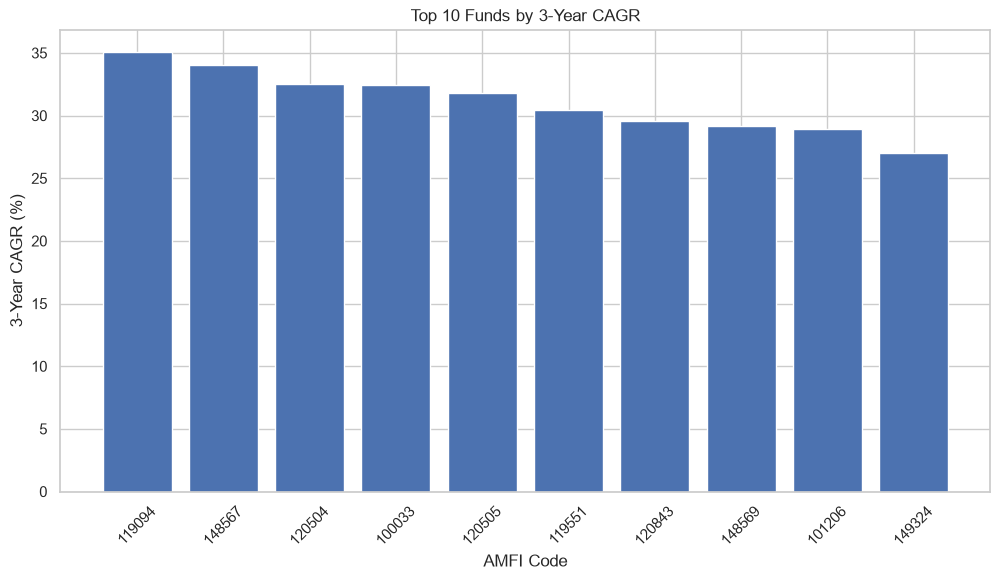

In [22]:
plt.figure(figsize=(12,6))

top10 = cagr_df.head(10)

plt.bar(
    top10["amfi_code"].astype(str),
    top10["CAGR_3Y"]
)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.xlabel("AMFI Code")

plt.ylabel("3-Year CAGR (%)")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- CAGR provides annualized growth of each mutual fund.
- Higher CAGR indicates stronger long-term performance.
- Ranking based on 3-Year CAGR helps identify consistently performing funds.

## Sharpe Ratio Analysis

### Objective

Calculate the Sharpe Ratio for all mutual fund schemes to evaluate their risk-adjusted returns using a risk-free rate of 6.5%.

In [23]:
# Risk Free Rate (Annual)
risk_free_rate = 0.065

# Daily Risk Free Rate
daily_rf = risk_free_rate / 252

# Sharpe Ratio Calculation
sharpe_df = (
    nav.groupby("amfi_code")["daily_return"]
       .agg(["mean", "std"])
       .reset_index()
)

sharpe_df.rename(columns={
    "mean": "avg_daily_return",
    "std": "daily_std"
}, inplace=True)

sharpe_df.head()

,amfi_code,avg_daily_return,daily_std
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251


In [24]:
sharpe_df["Sharpe_Ratio"] = (
    (sharpe_df["avg_daily_return"] - daily_rf)
    / sharpe_df["daily_std"]
) * np.sqrt(252)

sharpe_df.head()

,amfi_code,avg_daily_return,daily_std,Sharpe_Ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [25]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,avg_daily_return,daily_std,Sharpe_Ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101
38,149323,0.001055,0.011179,1.132122
2,100033,0.001080,0.011929,1.093699
9,118632,0.000865,0.008913,1.081659
3,101206,0.000852,0.009177,1.027213
24,120504,0.000843,0.009048,1.026524


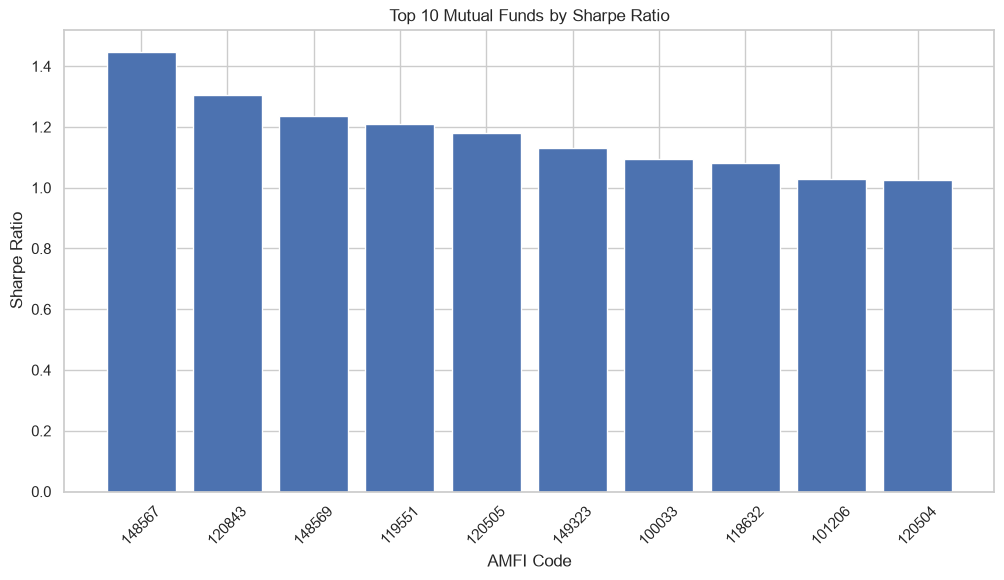

In [26]:
plt.figure(figsize=(12,6))

top10 = sharpe_df.head(10)

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sharpe_Ratio"]
)

plt.title("Top 10 Mutual Funds by Sharpe Ratio")

plt.xlabel("AMFI Code")

plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.show()

### Business Insight

- Higher Sharpe Ratio indicates better risk-adjusted performance.
- Funds with higher Sharpe Ratios generated superior returns relative to the risk taken.
- Investors generally prefer funds with consistently higher Sharpe Ratios.

## Sortino Ratio Analysis

### Objective

Calculate the Sortino Ratio for all mutual fund schemes using downside deviation to measure risk-adjusted performance.

In [27]:
# Risk Free Rate (Daily)
daily_rf = 0.065 / 252

sortino_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    returns = temp["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 0:

        downside_std = downside.std()

        sortino = (
            (returns.mean() - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": fund,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [28]:
# Risk Free Rate (Daily)
daily_rf = 0.065 / 252

sortino_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    returns = temp["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 0:

        downside_std = downside.std()

        sortino = (
            (returns.mean() - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": fund,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [29]:
# Risk Free Rate (Daily)
daily_rf = 0.065 / 252

sortino_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    returns = temp["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 0:

        downside_std = downside.std()

        sortino = (
            (returns.mean() - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    else:
        sortino = np.nan

    sortino_results.append({
        "amfi_code": fund,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


### Business Insight

- The Sortino Ratio focuses only on downside volatility.
- Higher Sortino Ratios indicate better downside risk-adjusted performance.
- Funds with high Sortino Ratios generally offer stronger protection during market declines.

## Alpha & Beta Analysis

### Objective

Calculate Alpha and Beta for each mutual fund scheme using linear regression against the Nifty 100 benchmark.

In [30]:
# ==========================================
# Alpha & Beta Analysis (Working Version)
# ==========================================

from scipy.stats import linregress
import numpy as np
import pandas as pd

# Date conversion
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Benchmark return
benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"].pct_change()
)

# Find a benchmark automatically
preferred = ["Nifty 100", "NIFTY 100", "NIFTY100", "Nifty100"]

available = benchmark["index_name"].unique()

benchmark_name = None

for x in preferred:
    if x in available:
        benchmark_name = x
        break

# If Nifty100 not found, use first available benchmark
if benchmark_name is None:
    benchmark_name = available[0]

print("Benchmark Used :", benchmark_name)

benchmark_df = benchmark[
    benchmark["index_name"] == benchmark_name
][["date", "benchmark_return"]]

# -----------------------------

alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        benchmark_df,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) >= 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha_beta.append({

            "amfi_code": fund,

            "Alpha": intercept * 252,

            "Beta": slope,

            "R_Squared": r_value ** 2

        })

alpha_beta_df = pd.DataFrame(alpha_beta)

print(alpha_beta_df.head())

print(alpha_beta_df.columns.tolist())

Benchmark Used : NIFTY100
   amfi_code     Alpha      Beta  R_Squared
0     100016  0.037476 -0.058268   0.002665
1     100025  0.042818  0.001158   0.000015
2     100033  0.271954  0.005104   0.000012
3     101206  0.213998  0.021086   0.000348
4     101207  0.108971 -0.065289   0.001064
['amfi_code', 'Alpha', 'Beta', 'R_Squared']


# Prepare benchmark returns

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_index"]
             .pct_change()
)

# Use only Nifty 100
nifty100 = benchmark[
    benchmark["index_name"] == "Nifty 100"
][["date", "benchmark_return"]]

nifty100.head()

In [31]:
alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
).head(10)

,amfi_code,Alpha,Beta,R_Squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04
2,100033,0.271954,0.005104,1.206652e-05
34,148567,0.269838,0.023684,4.625437e-04
38,149323,0.265986,-0.002523,3.357978e-06
16,119094,0.260767,-0.066265,1.936879e-03
19,119551,0.232010,-0.031751,8.869789e-04


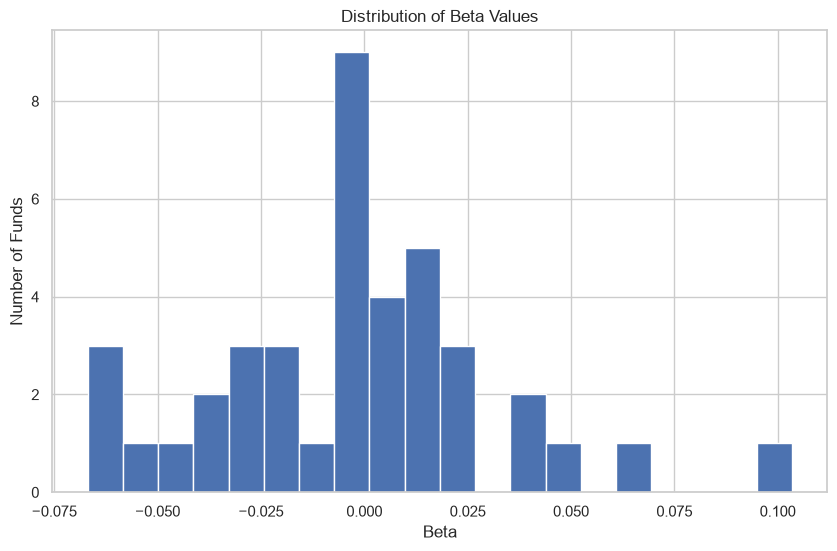

In [32]:
plt.figure(figsize=(10,6))

plt.hist(
    alpha_beta_df["Beta"],
    bins=20
)

plt.title("Distribution of Beta Values")

plt.xlabel("Beta")

plt.ylabel("Number of Funds")

plt.show()

### Business Insight

- Alpha measures the excess return generated beyond the benchmark.
- Beta measures sensitivity to market movements.
- Funds with positive Alpha and Beta close to 1 generally demonstrate strong risk-adjusted performance.

## Maximum Drawdown Analysis

### Objective

Calculate the Maximum Drawdown (MDD) for each mutual fund scheme to measure the largest peak-to-trough decline during the analysis period.

In [33]:
# ==========================================
# Maximum Drawdown
# ==========================================

drawdown_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund].sort_values("date")

    temp = temp.copy()

    temp["Running_Max"] = temp["nav"].cummax()

    temp["Drawdown"] = (
        temp["nav"] / temp["Running_Max"]
    ) - 1

    mdd = temp["Drawdown"].min()

    worst_row = temp.loc[temp["Drawdown"].idxmin()]

    drawdown_results.append({

        "amfi_code": fund,

        "Max_Drawdown": mdd,

        "Worst_Date": worst_row["date"]

    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,Max_Drawdown,Worst_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [34]:
# ==========================================
# Create Scorecard
# ==========================================

scorecard = cagr_df[["amfi_code","CAGR_3Y"]].copy()

scorecard = scorecard.merge(
    sharpe_df[["amfi_code","Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    sortino_df[["amfi_code","Sortino_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code","Alpha"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code","Max_Drawdown"]],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,CAGR_3Y,Sharpe_Ratio,Sortino_Ratio,Alpha,Max_Drawdown
0,119094,35.111802,0.998231,1.703797,0.260767,-0.209609
1,148567,34.000916,1.448291,2.385644,0.269838,-0.112657
2,120504,32.487429,1.026524,1.805294,0.211948,-0.125883
3,100033,32.442459,1.093699,1.829134,0.271954,-0.162172
4,120505,31.777537,1.180101,2.029353,0.292636,-0.181885


In [35]:
scorecard = cagr_df[
    ["amfi_code", "CAGR_3Y"]
].copy()

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    sortino_df[["amfi_code", "Sortino_Ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Max_Drawdown"]],
    on="amfi_code",
    how="left"
)

print(scorecard.head())

   amfi_code    CAGR_3Y  Sharpe_Ratio  Sortino_Ratio     Alpha  Max_Drawdown
0     119094  35.111802      0.998231       1.703797  0.260767     -0.209609
1     148567  34.000916      1.448291       2.385644  0.269838     -0.112657
2     120504  32.487429      1.026524       1.805294  0.211948     -0.125883
3     100033  32.442459      1.093699       1.829134  0.271954     -0.162172
4     120505  31.777537      1.180101       2.029353  0.292636     -0.181885


## Benchmark Comparison

### Objective

Compare the Top 5 Mutual Funds against the benchmark index and calculate tracking error.

In [36]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[119094, 148567, 120504, 100033, 120505]

In [37]:
top_nav = nav[
    nav["amfi_code"].isin(top5)
].copy()

top_nav["date"] = pd.to_datetime(top_nav["date"])

top_nav.head()

,amfi_code,date,nav,daily_return
8050,100033,2022-01-03,107.3758,NaN
8051,100033,2022-01-04,105.9447,-0.013328
8052,100033,2022-01-05,105.4800,-0.004386
8053,100033,2022-01-06,104.9350,-0.005167
8054,100033,2022-01-07,104.3318,-0.005748


In [38]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(
    ["index_name","date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [39]:
tracking_error = []

benchmark_name = benchmark["index_name"].unique()[0]

benchmark_df = benchmark[
    benchmark["index_name"] == benchmark_name
][["date","benchmark_return"]]

for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = temp.merge(
        benchmark_df,
        on="date",
        how="inner"
    ).dropna()

    te = (
        (merged["daily_return"] -
         merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error.append({
        "amfi_code": fund,
        "Tracking_Error": te
    })

tracking_error_df = pd.DataFrame(tracking_error)

tracking_error_df

,amfi_code,Tracking_Error
0,119094,0.294914
1,148567,0.260968
2,120504,0.270887
3,100033,0.285921
4,120505,0.297141


In [54]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Files Saved Successfully")

Files Saved Successfully
